# Multi-Layer Perceptron (MLP) exercise
author : [Maxime Devanne](https://www.maxime-devanne.com)

## Importing libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.utils import to_categorical

## Downloading the dataset of Pokemon images

In [ ]:
!wget 'https://www.maxime-devanne.com/datasets/Pokemon_images/X_train_hr.npy'
!wget 'https://www.maxime-devanne.com/datasets/Pokemon_images/y_train_hr.npy'
!wget 'https://www.maxime-devanne.com/datasets/Pokemon_images/X_test_hr.npy'
!wget 'https://www.maxime-devanne.com/datasets/Pokemon_images/y_test_hr.npy'

--2024-03-11 19:30:49--  https://www.maxime-devanne.com/datasets/Pokemon_images/X_train_hr.npy
Resolving www.maxime-devanne.com (www.maxime-devanne.com)... 213.186.33.4, 2001:41d0:1:1b00:213:186:33:4
Connecting to www.maxime-devanne.com (www.maxime-devanne.com)|213.186.33.4|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 160546853 (153M)
Saving to: ‘X_train_hr.npy’

X_train_hr.npy      100%[===================>] 153.11M  27.4MB/s    in 6.4s    

2024-03-11 19:30:56 (23.9 MB/s) - ‘X_train_hr.npy’ saved [160546853/160546853]

--2024-03-11 19:30:56--  https://www.maxime-devanne.com/datasets/Pokemon_images/y_train_hr.npy
Resolving www.maxime-devanne.com (www.maxime-devanne.com)... 213.186.33.4, 2001:41d0:1:1b00:213:186:33:4
Connecting to www.maxime-devanne.com (www.maxime-devanne.com)|213.186.33.4|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6712 (6.6K)
Saving to: ‘y_train_hr.npy’

y_train_hr.npy      100%[===================>]   6.55K

## Loading and preparing data

In [ ]:
# load data
X_train = np.load('X_train_hr.npy')
y_train = np.load('y_train_hr.npy')
X_test = np.load('X_test_hr.npy')
y_test = np.load('y_test_hr.npy')

# get information about image dimensions
width = int(X_train.shape[1])
height = int(X_train.shape[2])
n_channels = int(X_train.shape[3])

Image visualization

[0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


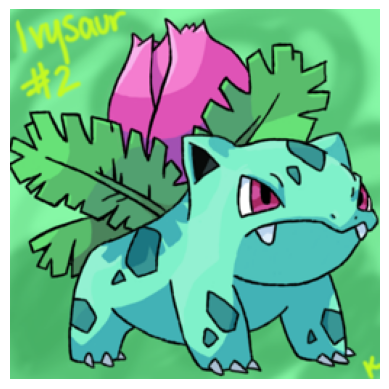

In [ ]:
id=8
plt.imshow(X_train[id])
plt.axis('off')
print(y_train[id])

Reshape the image into a 1D vector of pixels

In [ ]:
X_train = X_train.reshape((X_train.shape[0],X_train.shape[1]*X_train.shape[2]*X_train.shape[3]))
print(X_train.shape)

(823, 195075)


Transforming labels into "one-hot" vectors

In [ ]:
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

## Exercise

1. Build the following MLP:
*   Input data : an image of a pokemon
*   Two hidden layers of 512 neurons each, with ReLU activation
*   A final output layer for classification with 12 neurons (nb. of classes)
2. Train the MLP on the training set:
*   On 1000 epochs
*   Using a batch size of 16
*   Using the Adam optimizer
3. Evaluate the trained MLP on the test set

In [ ]:

# Reshape X_test the same way as X_train
X_test_flat = X_test.reshape((X_test.shape[0], X_test.shape[1] * X_test.shape[2] * X_test.shape[3]))

# 1. Build the MLP
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(width * height * n_channels,)),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(12, activation='softmax')
])

model.summary()

# 2. Compile and train
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train, y_train,
                    epochs=1000,
                    batch_size=16,
                    validation_split=0.1)

# 3. Evaluate on the test set
test_loss, test_acc = model.evaluate(X_test_flat, y_test)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")
